# Analisis Pola Pembelian Konsumen Menggunakan Algoritma Apriori Pada Dataset Online Retail

Nama : Muhamad Rifki Pudoli

NIM : 1224160053

Mata Kuliah : Konsep Data Warehouse & Mining

Dosen : Agus Rifaldi, S.Kom

Metode : Association Rule Mining (Apriori)

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import warnings
warnings.filterwarnings('ignore')

# Business Understanding

## Latar Belakang

Perusahaan retail menghasilkan data transaksi dalam jumlah besar setiap harinya. Data tersebut dapat dimanfaatkan untuk menemukan pola pembelian pelanggan sehingga perusahaan dapat mengetahui produk apa saja yang sering dibeli secara bersamaan.

## Tujuan

Menemukan hubungan antar produk menggunakan algoritma Apriori.

## Manfaat

- Mengetahui pola pembelian pelanggan
- Membantu strategi promosi
- Membantu paket bundling produk
- Meningkatkan penjualan

In [21]:
df = pd.read_csv("online_retail.csv")

df.head()
df.describe()
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

In [3]:
print("Jumlah Baris :", df.shape[0])
print("Jumlah Kolom :", df.shape[1])

Jumlah Baris : 541909
Jumlah Kolom : 8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

# Data Preparation

Tahapan:

1. Menghapus missing value
2. Menghapus transaksi retur
3. Menghapus transaksi cancel
4. Membentuk basket transaksi

In [6]:
df = df.dropna()

In [7]:
df = df[df['Quantity'] > 0]

In [8]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [9]:
print(df.shape)

(397924, 8)


In [10]:
top_produk = df['Description'].value_counts().head(10)

top_produk

Description
WHITE HANGING HEART T-LIGHT HOLDER    2028
REGENCY CAKESTAND 3 TIER              1724
JUMBO BAG RED RETROSPOT               1618
ASSORTED COLOUR BIRD ORNAMENT         1408
PARTY BUNTING                         1397
LUNCH BAG RED RETROSPOT               1316
SET OF 3 CAKE TINS PANTRY DESIGN      1159
LUNCH BAG  BLACK SKULL.               1105
POSTAGE                               1099
PACK OF 72 RETROSPOT CAKE CASES       1068
Name: count, dtype: int64

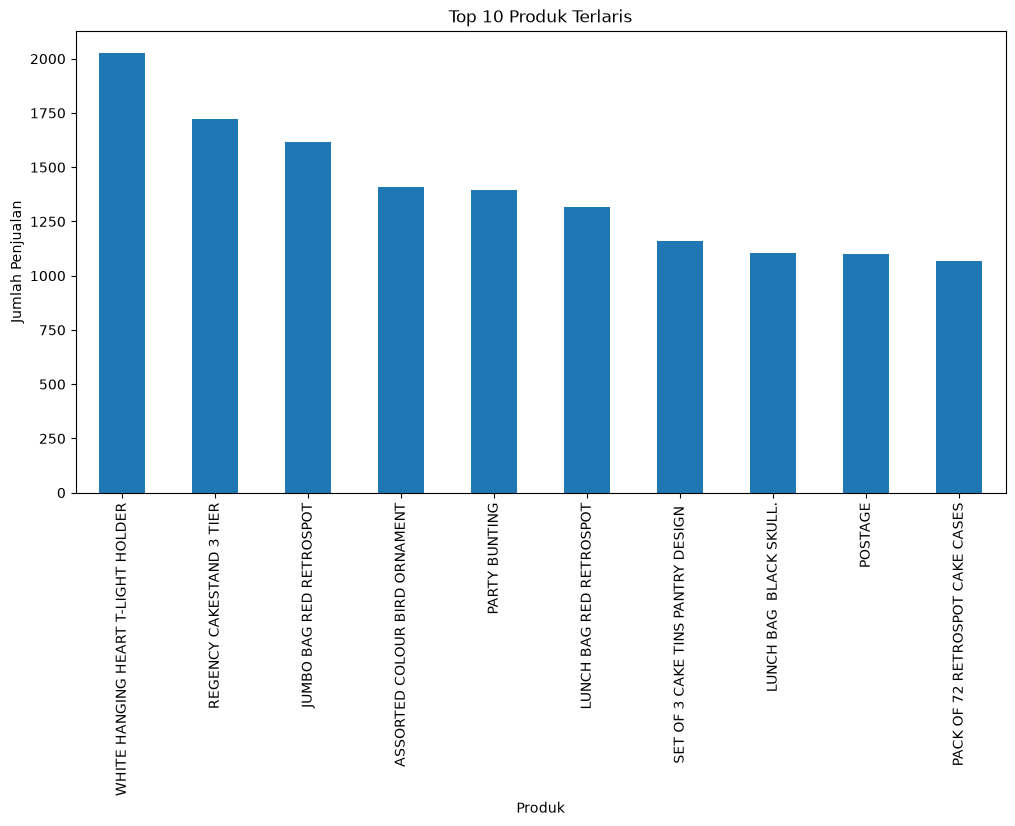

In [11]:
plt.figure(figsize=(12,6))

top_produk.plot(kind='bar')

plt.title("Top 10 Produk Terlaris")
plt.xlabel("Produk")
plt.ylabel("Jumlah Penjualan")

plt.show()

In [12]:
basket = (df.groupby(['InvoiceNo','Description'])['Quantity']
            .sum()
            .unstack()
            .reset_index()
            .fillna(0)
            .set_index('InvoiceNo'))

In [13]:
def encode(x):
    if x <= 0:
        return 0
    else:
        return 1

basket = basket.applymap(encode)

basket.head()

Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [74]:
basket = df.groupby('InvoiceNo')['Description'].apply(list)

basket.head()

InvoiceNo
536365    [WHITE HANGING HEART T-LIGHT HOLDER, WHITE MET...
536366    [HAND WARMER UNION JACK, HAND WARMER RED POLKA...
536367    [ASSORTED COLOUR BIRD ORNAMENT, POPPY'S PLAYHO...
536368    [JAM MAKING SET WITH JARS, RED COAT RACK PARIS...
536369                           [BATH BUILDING BLOCK WORD]
Name: Description, dtype: object

In [27]:
df_sales = df[df['Quantity'] > 0]

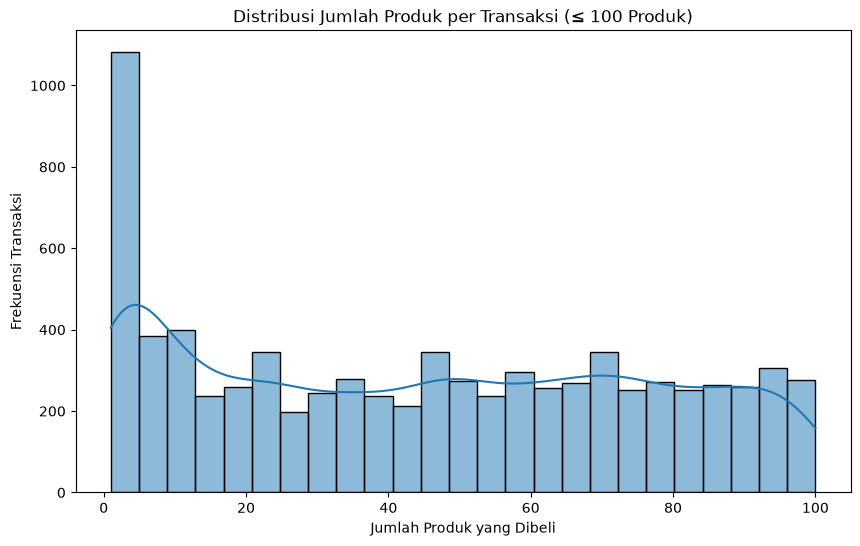

In [30]:
plt.figure(figsize=(10,6))
sns.histplot(
    transaction_quantity[transaction_quantity <= 100],
    bins=25,
    kde=True
)

plt.title('Distribusi Jumlah Produk per Transaksi (≤ 100 Produk)')
plt.xlabel('Jumlah Produk yang Dibeli')
plt.ylabel('Frekuensi Transaksi')

plt.show()

In [38]:
selected_features = df[['InvoiceNo', 'Description', 'Quantity']]

In [31]:
price_data = df[df['UnitPrice'] > 0]

Text(0, 0.5, 'Frekuensi')

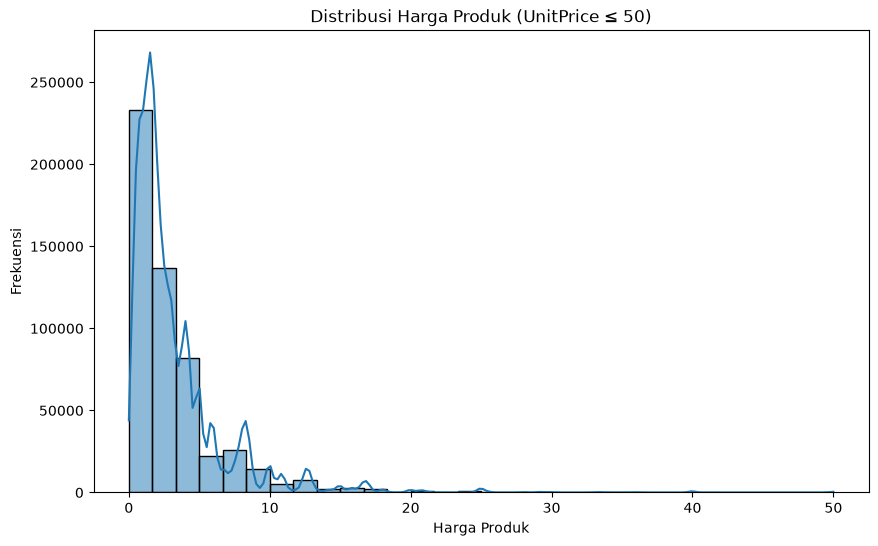

In [34]:
plt.figure(figsize=(10,6))
sns.histplot(
    price_data[price_data['UnitPrice'] <= 50]['UnitPrice'],
    bins=30,
    kde=True
)

plt.title('Distribusi Harga Produk (UnitPrice ≤ 50)')
plt.xlabel('Harga Produk')
plt.ylabel('Frekuensi')

In [35]:
df[['Quantity','UnitPrice']].corr()

,Quantity,UnitPrice
Quantity,1.000000,-0.001235
UnitPrice,-0.001235,1.000000


In [28]:
transaction_quantity = df_sales.groupby('InvoiceNo')['Quantity'].sum()

In [39]:
selected_features.head()

,InvoiceNo,Description,Quantity
0,536365,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,WHITE METAL LANTERN,6
2,536365,CREAM CUPID HEARTS COAT HANGER,8
3,536365,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,RED WOOLLY HOTTIE WHITE HEART.,6


# Modeling

Menggunakan Algoritma Apriori

In [91]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


In [41]:
from mlxtend.frequent_patterns import apriori

In [14]:
frequent_itemsets = apriori(
    basket,
    min_support=0.03,
    use_colnames=True
)

frequent_itemsets.head()

,support,itemsets
0,0.039167,(6 RIBBONS RUSTIC CHARM)
1,0.035445,(60 TEATIME FAIRY CAKE CASES)
2,0.042566,(ALARM CLOCK BAKELIKE GREEN)
3,0.033071,(ALARM CLOCK BAKELIKE PINK)
4,0.047313,(ALARM CLOCK BAKELIKE RED )


In [15]:
frequent_itemsets.sort_values(
    by='support',
    ascending=False
).head(10)

,support,itemsets
86,0.106334,(WHITE HANGING HEART T-LIGHT HOLDER)
69,0.091929,(REGENCY CAKESTAND 3 TIER)
35,0.086319,(JUMBO BAG RED RETROSPOT)
58,0.074450,(PARTY BUNTING)
5,0.074180,(ASSORTED COLOUR BIRD ORNAMENT)
47,0.069486,(LUNCH BAG RED RETROSPOT)
75,0.061826,(SET OF 3 CAKE TINS PANTRY DESIGN )
63,0.059290,(POSTAGE)
41,0.056754,(LUNCH BAG BLACK SKULL.)
54,0.055514,(PACK OF 72 RETROSPOT CAKE CASES)


<Axes: xlabel='Description'>

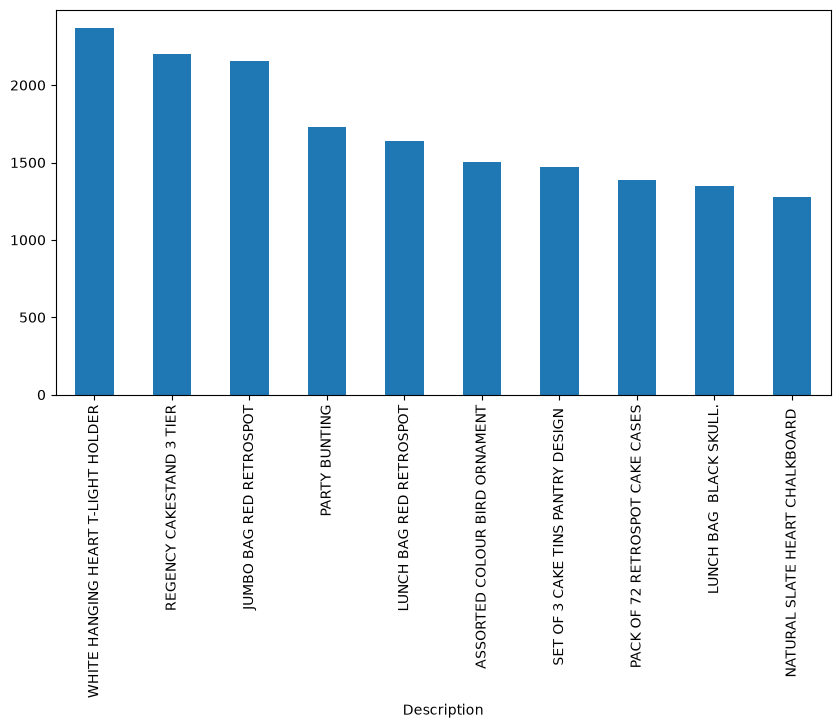

In [57]:
top_produk = df['Description'].value_counts().head(10)

top_produk.plot(
    kind='bar',
    figsize=(10,5)
)

In [88]:
rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']]

,antecedents,consequents,support,confidence,lift
0,(6 RIBBONS RUSTIC CHARM),(DOTCOM POSTAGE),0.010459,0.211518,5.770148
1,(DOTCOM POSTAGE),(6 RIBBONS RUSTIC CHARM),0.010459,0.285311,5.770148
2,(6 RIBBONS RUSTIC CHARM),(JAM MAKING SET PRINTED),0.012219,0.247120,4.107473
3,(JAM MAKING SET PRINTED),(6 RIBBONS RUSTIC CHARM),0.012219,0.203098,4.107473
4,(6 RIBBONS RUSTIC CHARM),(JAM MAKING SET WITH JARS),0.010718,0.216754,3.694956
...,...,...,...,...,...
3479,(CHARLOTTE BAG SUKI DESIGN),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.010562,0.231293,18.459437
3480,(RED RETROSPOT CHARLOTTE BAG),"(STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG PINK ...",0.010562,0.197292,17.164410
3481,(CHARLOTTE BAG PINK POLKADOT),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.010562,0.274563,20.395776
3482,(STRAWBERRY CHARLOTTE BAG),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.010562,0.282548,21.741599


In [58]:
rules = rules.sort_values(
    by='lift',
    ascending=False
)

rules.head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


# Evaluation

Evaluasi dilakukan menggunakan:

- Support
- Confidence
- Lift

Rule dengan confidence di atas 80% dianggap memiliki hubungan yang kuat.

Nilai lift lebih dari 1 menunjukkan adanya hubungan positif antar produk.

In [90]:
rules.sort_values(
    by='confidence',
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
1834,"(SUKI SHOULDER BAG, JAM MAKING SET PRINTED)",(DOTCOM POSTAGE),0.011287,0.036657,0.010821,0.958716,26.153436,1.0,0.010407,23.334300,0.972744,0.291492,0.957145,0.626957
3163,"(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...",(RED RETROSPOT CHARLOTTE BAG),0.013617,0.053536,0.012530,0.920152,17.187444,1.0,0.011801,11.853331,0.954820,0.229384,0.915636,0.577097
3457,"(STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG PINK ...",(RED RETROSPOT CHARLOTTE BAG),0.011494,0.053536,0.010562,0.918919,17.164410,1.0,0.009947,11.673052,0.952690,0.193916,0.914333,0.558105
3233,"(ROSES REGENCY TEACUP AND SAUCER , REGENCY CAK...",(GREEN REGENCY TEACUP AND SAUCER),0.017138,0.052553,0.015585,0.909366,17.303927,1.0,0.014684,10.453504,0.958639,0.288038,0.904338,0.602959
2010,"(ROSES REGENCY TEACUP AND SAUCER , PINK REGENC...",(GREEN REGENCY TEACUP AND SAUCER),0.031014,0.052553,0.028063,0.904841,17.217839,1.0,0.026433,9.956509,0.972068,0.505597,0.899563,0.719416
3121,"(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...",(RED RETROSPOT CHARLOTTE BAG),0.014031,0.053536,0.012685,0.904059,16.886844,1.0,0.011934,9.865064,0.954171,0.231132,0.898632,0.570501
1926,"(SUKI SHOULDER BAG, JUMBO BAG RED RETROSPOT)",(DOTCOM POSTAGE),0.014601,0.036657,0.012892,0.882979,24.087360,1.0,0.012357,8.232201,0.972686,0.336032,0.878526,0.617337
3232,"(GREEN REGENCY TEACUP AND SAUCER, REGENCY CAKE...",(ROSES REGENCY TEACUP AND SAUCER ),0.017759,0.055193,0.015585,0.877551,15.899644,1.0,0.014604,7.715923,0.954049,0.271661,0.870398,0.579957
2004,"(REGENCY CAKESTAND 3 TIER, PINK REGENCY TEACUP...",(GREEN REGENCY TEACUP AND SAUCER),0.020296,0.052553,0.017759,0.875000,16.650000,1.0,0.016693,7.579580,0.959412,0.322368,0.868067,0.606466
3261,"(JUMBO BAG PINK POLKADOT, JUMBO BAG BAROQUE B...",(JUMBO BAG RED RETROSPOT),0.012219,0.108315,0.010666,0.872881,8.058714,1.0,0.009342,7.014587,0.886746,0.097078,0.857440,0.485676


In [69]:
rules_positive = rules[rules['lift'] > 1]

rules_positive[['antecedents',
                'consequents',
                'support',
                'confidence',
                'lift']].sort_values(
                    by='lift',
                    ascending=False
                ).head(10)

,antecedents,consequents,support,confidence,lift


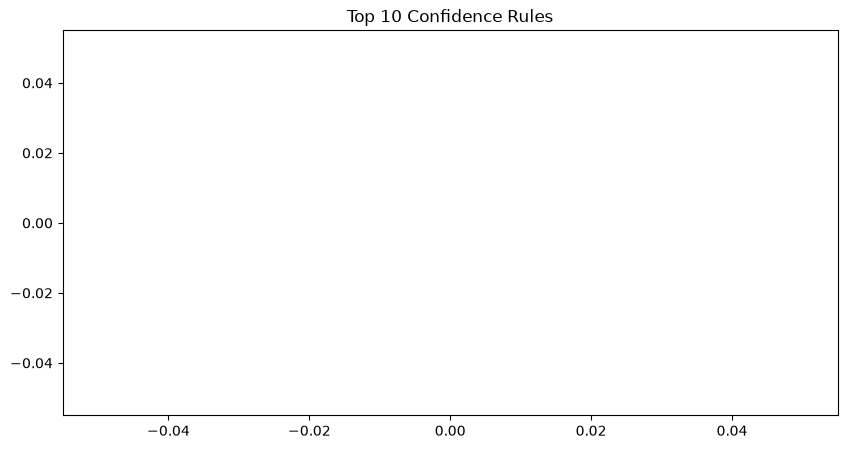

In [20]:
top_rules = rules.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    range(len(top_rules)),
    top_rules['confidence']
)

plt.title("Top 10 Confidence Rules")

plt.show()

# Conclusion

Berdasarkan hasil analisis menggunakan algoritma Apriori pada dataset Online Retail, ditemukan beberapa pola pembelian produk yang sering terjadi secara bersamaan.

Aturan asosiasi yang dihasilkan memiliki nilai confidence di atas 80% dan nilai lift lebih dari 1 sehingga menunjukkan hubungan yang kuat antar produk.

Hasil analisis dapat digunakan sebagai dasar strategi promosi, bundling produk, dan penempatan produk yang lebih efektif.

In [81]:
top_products = (
    df['Description']
    .value_counts()
    .head(200)
    .index
)

df_top = df[df['Description'].isin(top_products)]

In [82]:
basket = (
    df_top.groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum()
          .unstack()
          .fillna(0)
)
    
basket_sets = (basket > 0).astype(int)

In [83]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket_sets,
    min_support=0.01,
    use_colnames=True,
    low_memory=True
)

In [85]:
rules[['antecedents',
       'consequents',
       'support']]

,antecedents,consequents,support
0,(6 RIBBONS RUSTIC CHARM),(DOTCOM POSTAGE),0.010459
1,(DOTCOM POSTAGE),(6 RIBBONS RUSTIC CHARM),0.010459
2,(6 RIBBONS RUSTIC CHARM),(JAM MAKING SET PRINTED),0.012219
3,(JAM MAKING SET PRINTED),(6 RIBBONS RUSTIC CHARM),0.012219
4,(6 RIBBONS RUSTIC CHARM),(JAM MAKING SET WITH JARS),0.010718
...,...,...,...
3479,(CHARLOTTE BAG SUKI DESIGN),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.010562
3480,(RED RETROSPOT CHARLOTTE BAG),"(STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG PINK ...",0.010562
3481,(CHARLOTTE BAG PINK POLKADOT),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.010562
3482,(STRAWBERRY CHARLOTTE BAG),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.010562


In [86]:
rules[['antecedents',
       'consequents',
       'confidence']]

,antecedents,consequents,confidence
0,(6 RIBBONS RUSTIC CHARM),(DOTCOM POSTAGE),0.211518
1,(DOTCOM POSTAGE),(6 RIBBONS RUSTIC CHARM),0.285311
2,(6 RIBBONS RUSTIC CHARM),(JAM MAKING SET PRINTED),0.247120
3,(JAM MAKING SET PRINTED),(6 RIBBONS RUSTIC CHARM),0.203098
4,(6 RIBBONS RUSTIC CHARM),(JAM MAKING SET WITH JARS),0.216754
...,...,...,...
3479,(CHARLOTTE BAG SUKI DESIGN),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.231293
3480,(RED RETROSPOT CHARLOTTE BAG),"(STRAWBERRY CHARLOTTE BAG, CHARLOTTE BAG PINK ...",0.197292
3481,(CHARLOTTE BAG PINK POLKADOT),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.274563
3482,(STRAWBERRY CHARLOTTE BAG),"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.282548


In [84]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1
)

rules.sort_values(
    by='lift',
    ascending=False
)[['antecedents',
   'consequents',
   'support',
   'confidence',
   'lift']].head(10)

,antecedents,consequents,support,confidence,lift
3461,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...","(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...",0.010562,0.607143,30.940256
3476,"(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.010562,0.538259,30.940256
3477,"(CHARLOTTE BAG PINK POLKADOT, WOODLAND CHARLOT...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.010562,0.516456,29.864746
3460,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...","(CHARLOTTE BAG PINK POLKADOT, WOODLAND CHARLOT...",0.010562,0.610778,29.864746
3468,"(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.010562,0.775665,29.548721
3469,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...","(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...",0.010562,0.402367,29.548721
3459,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...","(STRAWBERRY CHARLOTTE BAG, WOODLAND CHARLOTTE ...",0.010562,0.620061,29.497178
3478,"(STRAWBERRY CHARLOTTE BAG, WOODLAND CHARLOTTE ...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.010562,0.502463,29.497178
3470,"(CHARLOTTE BAG PINK POLKADOT, CHARLOTTE BAG SU...","(RED RETROSPOT CHARLOTTE BAG, STRAWBERRY CHARL...",0.010562,0.497561,29.388051
3467,"(RED RETROSPOT CHARLOTTE BAG, STRAWBERRY CHARL...","(CHARLOTTE BAG PINK POLKADOT, CHARLOTTE BAG SU...",0.010562,0.623853,29.388051


In [87]:
rules.sort_values(
    by='lift',
    ascending=False
).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3461,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...","(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...",0.017397,0.019623,0.010562,0.607143,30.940256,1.0,0.010221,2.495505,0.984812,0.399217,0.599279,0.572701
3476,"(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.019623,0.017397,0.010562,0.538259,30.940256,1.0,0.010221,2.128038,0.987049,0.399217,0.530084,0.572701
3477,"(CHARLOTTE BAG PINK POLKADOT, WOODLAND CHARLOT...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.020451,0.017293,0.010562,0.516456,29.864746,1.0,0.010209,2.032299,0.986695,0.388571,0.507947,0.563617
3460,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...","(CHARLOTTE BAG PINK POLKADOT, WOODLAND CHARLOT...",0.017293,0.020451,0.010562,0.610778,29.864746,1.0,0.010209,2.516686,0.983524,0.388571,0.602652,0.563617
3468,"(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...",0.013617,0.026250,0.010562,0.775665,29.548721,1.0,0.010205,4.340613,0.979495,0.360424,0.769618,0.589016
3469,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG SU...","(CHARLOTTE BAG PINK POLKADOT, STRAWBERRY CHARL...",0.026250,0.013617,0.010562,0.402367,29.548721,1.0,0.010205,1.650482,0.992203,0.360424,0.394117,0.589016
3459,"(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...","(STRAWBERRY CHARLOTTE BAG, WOODLAND CHARLOTTE ...",0.017034,0.021021,0.010562,0.620061,29.497178,1.0,0.010204,2.576673,0.982840,0.384181,0.611903,0.561262
3478,"(STRAWBERRY CHARLOTTE BAG, WOODLAND CHARLOTTE ...","(RED RETROSPOT CHARLOTTE BAG, CHARLOTTE BAG PI...",0.021021,0.017034,0.010562,0.502463,29.497178,1.0,0.010204,1.975664,0.986843,0.384181,0.493841,0.561262
3470,"(CHARLOTTE BAG PINK POLKADOT, CHARLOTTE BAG SU...","(RED RETROSPOT CHARLOTTE BAG, STRAWBERRY CHARL...",0.021228,0.016931,0.010562,0.497561,29.388051,1.0,0.010203,1.956594,0.986923,0.382739,0.488908,0.560707
3467,"(RED RETROSPOT CHARLOTTE BAG, STRAWBERRY CHARL...","(CHARLOTTE BAG PINK POLKADOT, CHARLOTTE BAG SU...",0.016931,0.021228,0.010562,0.623853,29.388051,1.0,0.010203,2.602101,0.982609,0.382739,0.615695,0.560707
